# Reading raw SmartSolo DLD files directly

`lib/smartsolo_dld.py` reads the node's own `seisNNN{X,Y,Z}.DLD` files – no SoloLite export needed – and plugs them into the location/selection/extraction tools, which write MiniSEED, SEG-Y and StationXML. Format notes: [`docs/DLD_FORMAT.md`](../docs/DLD_FORMAT.md); what was learned along the way: [`docs/FINDINGS.md`](../docs/FINDINGS.md).

Data: the four complete UTAS nodes in `data/break_test/` (stored with Git LFS – run `git lfs pull` after cloning). See `break_test.ipynb` for the science.

In [1]:
import sys; sys.path.insert(0, "../lib")
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from obspy import UTCDateTime, read
import smartsolo_dld as dld, smartsolo_locate as loc, smartsolo_waveforms as wf
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
BT = Path("../data/break_test")
dld_files = sorted(BT.rglob("*.DLD")); [str(f.relative_to(BT)) for f in dld_files][:6]

['453009194/20230407041120/seis000X.DLD',
 '453009194/20230407041120/seis000Y.DLD',
 '453009194/20230407041120/seis000Z.DLD',
 '453009194/20230407041120/seis001X.DLD',
 '453009194/20230407041120/seis001Y.DLD',
 '453009194/20230407041120/seis001Z.DLD']

## 1. File header
Serial, firmware, start/end, position, script – so files can be identified even if renamed or mixed up. Note: the header position is the position **when the file was closed** (453010047 had already been picked up and carried ~180 m when seis000 was closed); use the tag positions instead.

In [2]:
hdr = pd.DataFrame([dld.read_dld_header(f) for f in dld_files if f.stem.endswith("Z")])
hdr[["serial", "file_index", "firmware", "project_name", "start", "end", "duration_s", "latitude", "longitude", "altitude", "leap_seconds", "file_size"]]

,serial,file_index,firmware,project_name,start,end,duration_s,latitude,longitude,altitude,leap_seconds,file_size
0,453009194,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:30:55+00:00,2023-03-31 01:59:17+00:00,1702.0,-42.903794,147.327997,60.200001,0,2617856
1,453009194,1,V1.0.5.6kp,UTASTesting,2023-04-06 23:45:25+00:00,2023-04-07 04:11:21+00:00,15958.0,-42.866476,147.322673,92.599998,18,24515072
2,453010047,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:28:23+00:00,2023-03-31 01:59:09+00:00,1846.0,-42.903873,147.327797,40.599998,0,2839040
3,453010047,1,V1.0.5.6kp,UTASTesting,2023-04-06 23:46:55+00:00,2023-04-07 04:10:27+00:00,15814.0,-42.866356,147.322570,92.599998,18,24293888
4,453010077,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:33:25+00:00,2023-03-31 02:00:11+00:00,1606.0,-42.902253,147.329660,24.799999,0,2470400
5,453010077,1,V1.0.5.6kp,UTASTesting,2023-04-06 23:45:17+00:00,2023-04-07 04:05:13+00:00,15598.0,-42.866591,147.322783,92.900002,18,23962112
6,453010167,0,V1.0.5.6kp,UTASTesting,2023-03-31 01:34:41+00:00,2023-03-31 01:58:39+00:00,1438.0,-42.902262,147.329663,28.900000,0,2212352
7,453010167,1,V1.0.5.6kp,UTASTesting,2023-04-06 23:47:17+00:00,2023-04-07 04:09:13+00:00,15718.0,-42.866233,147.322461,92.500000,18,24146432


## 2. Time tags
After every 1000 samples: a 72-byte tag with a ms tick, the UTC time as text, GPS position, GPS time of week (TOW) and two counters. The tick step gives the sample rate: 2000 ms per 1000 samples → 500 sps.

In [3]:
f = next((BT / "453009194").glob("*/seis001Z.DLD"))
tags = dld.read_dld_tags(f)
print(len(tags), "tags; tick steps:", tags.tick_ms.diff().value_counts().to_dict())
tags.iloc[[0, 1, 2195, 2196, 2197, 2198, -1]][["block", "tick_ms", "time_label", "time_tow", "label_minus_tow_s", "phase_error", "counter", "latitude", "longitude"]]

7980 tags; tick steps: {2000.0: 7979}


,block,tick_ms,time_label,time_tow,label_minus_tow_s,phase_error,counter,latitude,longitude
0,0,9689877361776,2023-04-06 23:45:25+00:00,2023-04-06 23:45:23+00:00,2.0,0,0,-42.866475,147.322664
1,1,9689877363776,2023-04-06 23:45:27+00:00,2023-04-06 23:45:25+00:00,2.0,0,0,-42.866475,147.322663
2195,2195,9689881751776,2023-04-07 00:58:35+00:00,2023-04-07 00:58:33+00:00,2.0,1,200,-42.866469,147.322665
2196,2196,9689881753776,2023-04-07 00:58:37+00:00,2023-04-07 00:58:35+00:00,2.0,1,400,-42.866469,147.322665
2197,2197,9689881755776,2023-04-07 00:58:37+00:00,2023-04-07 00:58:37+00:00,0.0,0,0,-42.866468,147.322664
2198,2198,9689881757776,2023-04-07 00:58:39+00:00,2023-04-07 00:58:39+00:00,0.0,0,200,-42.866468,147.322664
7979,7979,9689893319776,2023-04-07 04:11:21+00:00,2023-04-07 04:11:21+00:00,0.0,0,19800,-42.866477,147.322673


### Which time to trust: text label or GPS time of week?
At block 2197 the text label repeats `00:58:37` – the labels jump back 2 s while the tick and TOW run on. Before the jump the labels are 2 s ahead of TOW-derived UTC, after it they agree. The header field `leap_seconds` is 0 in files written before the receiver knew the GPS–UTC offset and 18 after. Interpretation: until the almanac delivers the leap seconds the receiver uses an old default (16 s instead of 18), so labels are 2 s late; TOW (time of the *next* pulse, hence −1 s) is unaffected.

Proof with real data: cross-correlating ambient noise between pairs of nodes every 10 minutes, label times show 2-s steps exactly when one node's labels jump; TOW times give zero lag throughout. `time_source="tow"` is therefore the default.

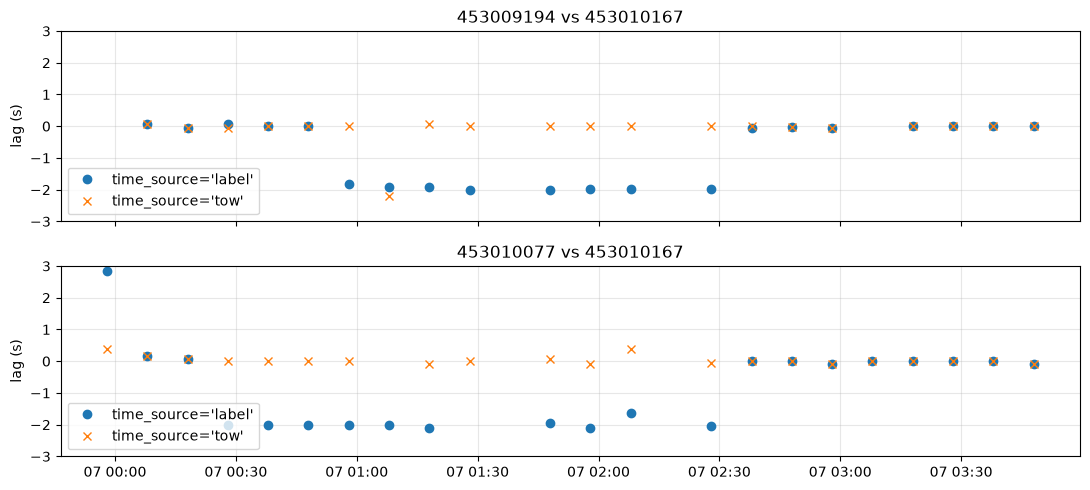

In [4]:
from obspy.signal.cross_correlation import correlate, xcorr_max
def lag_series(a, b, src, t0="2023-04-06T23:58", t1="2023-04-07T04:00", win=120, step=600):
    fa = next((BT / a).glob("*/seis001Z.DLD")); fb = next((BT / b).glob("*/seis001Z.DLD"))
    out, t = [], UTCDateTime(t0)
    while t < UTCDateTime(t1):
        x = dld.read_dld(fa, starttime=t, endtime=t + win, time_source=src)
        y = dld.read_dld(fb, starttime=t, endtime=t + win, time_source=src)
        x.merge(fill_value=0); y.merge(fill_value=0); x, y = x[0], y[0]
        for tr in (x, y): tr.detrend("demean"); tr.filter("bandpass", freqmin=2, freqmax=40)
        n = min(x.stats.npts, y.stats.npts)
        lag, cc = xcorr_max(correlate(x.data[:n], y.data[:n], 1500), abs_max=False)
        out.append((t.datetime, lag / 500, cc)); t += step
    return pd.DataFrame(out, columns=["time", "lag_s", "cc"]).set_index("time")

pairs = [("453009194", "453010167"), ("453010077", "453010167")]
fig, axes = plt.subplots(len(pairs), 1, figsize=(11, 5), sharex=True)
for ax, (a, b) in zip(axes, pairs):
    for src, mk in [("label", "o"), ("tow", "x")]:
        s = lag_series(a, b, src); s = s[s.cc > 0.05]
        ax.plot(s.index, s.lag_s, mk, label=f"time_source='{src}'")
    ax.set(ylabel="lag (s)", title=f"{a} vs {b}", ylim=(-3, 3)); ax.grid(alpha=.3); ax.legend(loc="lower left")
plt.tight_layout()

## 3. Read samples

3 Trace(s) in Stream:
.10077..X | 2023-03-31T01:33:23.000000Z - 2023-03-31T02:00:10.998000Z | 500.0 Hz, 804000 samples
.10077..Y | 2023-03-31T01:33:23.000000Z - 2023-03-31T02:00:10.998000Z | 500.0 Hz, 804000 samples
.10077..Z | 2023-03-31T01:33:23.000000Z - 2023-03-31T02:00:10.998000Z | 500.0 Hz, 804000 samples


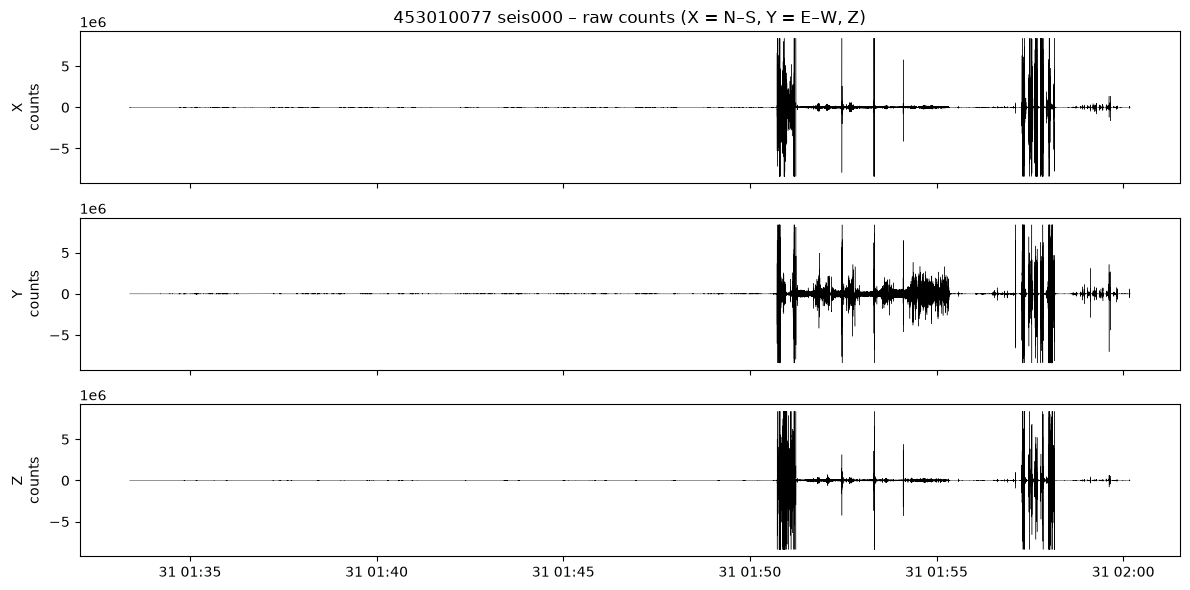

In [5]:
st = dld.read_dld_node(sorted((BT / "453010077").glob("*/seis000?.DLD")))
print(st)
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for a, tr in zip(axes, st):
    a.plot(tr.times("matplotlib"), tr.data, lw=.3, color="k"); a.set_ylabel(f"{tr.stats.channel}\ncounts")
axes[0].set_title("453010077 seis000 – raw counts (X = N–S, Y = E–W, Z)"); axes[-1].xaxis_date(); plt.tight_layout()

Samples run on smoothly across the 72-byte tags:

In [6]:
tr = st.select(channel="Z")[0]
d = np.abs(np.diff(tr.data.astype(float)))
print("median |Δ| at block boundaries:", np.median(d[999::1000]), " elsewhere:", np.median(d))

median |Δ| at block boundaries: 110.0  elsewhere: 107.0


## 4. Deployments from logs and DLD, select, cut, write MiniSEED / SEG-Y / StationXML

In [7]:
deps = loc.combine_deployments(loc.build_deployments(BT), loc.build_deployments_from_dld(BT))
deps[["deployment_id", "source", "start", "end", "latitude", "longitude", "sample_rate_hz", "channel_1_gain"]]

,deployment_id,source,start,end,latitude,longitude,sample_rate_hz,channel_1_gain
0,453009194_002,log,2023-03-31 01:30:53+00:00,2023-03-31 01:59:16.998000+00:00,-42.902456,147.329333,500.0,0.0
1,453009194_003,log,2023-04-06 23:45:23+00:00,2023-04-07 04:11:22.998000+00:00,-42.866477,147.322654,500.0,0.0
2,453010047_002,log,2023-03-31 01:28:21+00:00,2023-03-31 01:59:08.998000+00:00,-42.902653,147.329122,500.0,0.0
3,453010047_003,log,2023-04-06 23:46:53+00:00,2023-04-07 04:10:28.998000+00:00,-42.866343,147.322560,500.0,0.0
4,453010077_002,log,2023-03-31 01:33:23+00:00,2023-03-31 02:00:10.998000+00:00,-42.901756,147.330097,500.0,0.0
5,453010077_003,log,2023-04-06 23:45:15+00:00,2023-04-07 04:05:14.998000+00:00,-42.866594,147.322763,500.0,0.0
6,453010167_003,log,2023-03-31 01:34:39+00:00,2023-03-31 01:58:38.998000+00:00,-42.901671,147.330223,500.0,0.0
7,453010167_004,log,2023-04-06 23:47:15+00:00,2023-04-07 04:09:14.998000+00:00,-42.866224,147.322451,500.0,0.0


In [8]:
index = wf.index_waveforms(BT)
sel = loc.select_deployments(deps, point=(-42.9017, 147.3301), radius_km=0.03,
                             start="2023-03-31T01:40:30", end="2023-03-31T01:41:30")
out = Path("../output/dld_demo")
st_m = wf.extract_waveforms(sel, index, out_dir=out / "mseed", out_format="MSEED")
st_s = wf.extract_waveforms(sel, index, out_dir=out / "segy", out_format="SEGY")
inv = wf.build_inventory(sel, stream=st_m, response="auspass"); inv.write(str(out / "stations.xml"), format="STATIONXML")
print(st_m); print(sorted(str(p.relative_to(out)) for p in out.rglob("*") if p.is_file()))

6 Trace(s) in Stream:
XX.10077..DPE | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10077..DPN | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10077..DPZ | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10167..DPE | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10167..DPN | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
XX.10167..DPZ | 2023-03-31T01:40:30.000000Z - 2023-03-31T01:41:29.998000Z | 500.0 Hz, 30000 samples
['mseed/XX/10077/XX.10077..DPE__20230331T014030Z__20230331T014130Z.mseed', 'mseed/XX/10077/XX.10077..DPN__20230331T014030Z__20230331T014130Z.mseed', 'mseed/XX/10077/XX.10077..DPZ__20230331T014030Z__20230331T014130Z.mseed', 'mseed/XX/10167/XX.10167..DPE__20230331T014030Z__20230331T014130Z.mseed', 'mseed/XX/10167/XX.10167..DPN__20230331T014030Z__20230331T014130Z.mseed', 'mseed/

In [9]:
raw = dld.read_dld(next((BT / "453010077").glob("*/seis000Z.DLD")), starttime="2023-03-31T01:40:30", endtime="2023-03-31T01:41:29.998")[0]
m = read(str(next((out / "mseed").rglob("*10077..DPZ*"))))[0]; s = read(str(next((out / "segy").rglob("*10077..DPZ*"))), format="SEGY")[0]
print(m.stats.starttime, s.stats.starttime, raw.stats.starttime)
print("MiniSEED == -DLD:", np.array_equal(m.data, -raw.data), "  SEG-Y == MiniSEED:", np.array_equal(s.data, m.data))

2023-03-31T01:40:30.000000Z 2023-03-31T01:40:30.000000Z 2023-03-31T01:40:30.000000Z
MiniSEED == -DLD: True   SEG-Y == MiniSEED: True


## 5. One call for a whole drive
```python
sel, inv, files = wf.convert_dld('/media/drive', out_dir='out', log_root='/media/drive', out_format='MSEED', chunk='1D')
```
Not run here to keep the repository output small (it would convert all ~300 MB).